<a href="https://colab.research.google.com/github/ydchen17/PPI_Analysis_Project/blob/main/NetworkAnalysis(original).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install biopython
! pip install networkx
import networkx as nx
import pandas as pd
import Bio

### Load PPI nodes and edges

In [ ]:
def nodelist(edge_list):
  return list(set.union(set(edge_list["protein1"]), set(edge_list["protein2"])))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# human ppi is downloaded from:
# https://stringdb-static.org/download/protein.links.v11.5/9606.protein.links.v11.5.txt.gz
human_ppi_path = "/content/drive/MyDrive/Network_GroupProject/string_human.txt"
human_ppi_edges = pd.read_csv(human_ppi_path, sep = " ")
human_ppi_nodes = nodelist(human_ppi_edges)
print(human_ppi_edges.head())
print(len(human_ppi_edges), len(human_ppi_nodes))

               protein1              protein2  combined_score
0  9606.ENSP00000000233  9606.ENSP00000379496             155
1  9606.ENSP00000000233  9606.ENSP00000314067             197
2  9606.ENSP00000000233  9606.ENSP00000263116             222
3  9606.ENSP00000000233  9606.ENSP00000361263             181
4  9606.ENSP00000000233  9606.ENSP00000409666             270
11938498 19385


In [ ]:
# yeast ppi is downloaded from:
# https://stringdb-static.org/download/protein.links.v11.5/4932.protein.links.v11.5.txt.gz
yeast_ppi_path = "/content/drive/MyDrive/Network_GroupProject/string_yeast.txt"
yeast_ppi_edges = pd.read_csv(yeast_ppi_path, sep = " ")
yeast_ppi_nodes = nodelist(yeast_ppi_edges)
print(yeast_ppi_edges.head())
print(len(yeast_ppi_edges), len(yeast_ppi_nodes))

     protein1      protein2  combined_score
0  4932.Q0010  4932.YPL135W             347
1  4932.Q0010    4932.Q0017             945
2  4932.Q0010  4932.YOL103W             163
3  4932.Q0010  4932.YJR122W             528
4  4932.Q0010  4932.YGL043W             284
1988592 6394


### Retrieve homolog from API

In [ ]:
# search for homolog (the simple way)
# https://rest.ensembl.org/documentation/info/homology_ensemblgene

import requests, sys, json
def human_homolog_search(gene):
  ID = gene[5:]
  server = "https://rest.ensembl.org"
  ext = "/homology/id/"+ID+"?target_species=human"
  try:
    r = requests.get(server+ext, headers={ "Content-Type" : "application/json"})
    decoded = r.json()
    output = "9606."+str(decoded["data"][0]['homologies'][0]['target']['protein_id'])
  except:
    output = "yeast_specific"
  return output

In [ ]:
print(human_homolog_search("4932.YPL135W"), human_homolog_search("4932.YPL1234"))

9606.ENSP00000310623 yeast_specific


In [ ]:
yeast_to_human_homolog = {"yeast_protein":[], "human_homolog":[]}
for i in yeast_ppi_nodes:
  yeast_to_human_homolog["yeast_protein"].append(i)
  yeast_to_human_homolog["human_homolog"].append(human_homolog_search(i))
yeast_to_human_homolog = pd.DataFrame(yeast_to_human_homolog)

In [ ]:
yeast_to_human_homolog["yeast_protein"].value_counts()
yeast_to_human_homolog["human_homolog"].value_counts()
# shared human homolog?

yeast_specific          3745
9606.ENSP00000369213      29
9606.ENSP00000075120      24
9606.ENSP00000306606      18
9606.ENSP00000493218      14
                        ... 
9606.ENSP00000406046       1
9606.ENSP00000295121       1
9606.ENSP00000324302       1
9606.ENSP00000342889       1
9606.ENSP00000253237       1
Name: human_homolog, Length: 2086, dtype: int64

In [ ]:
# "9606.ENSP00000409952" in list(yeast_to_human_homolog['human_homolog'])

### Evolution Annotation (simple match)

In [ ]:
protein_evo = {"human_protein":[], "yeast_protein":[], "evo_status":[]}
for i in yeast_to_human_homolog.iterrows():
  if i[1]["human_homolog"] == "yeast_specific":
    protein_evo["human_protein"].append(None)
    protein_evo["yeast_protein"].append(i[1]["yeast_protein"])
    protein_evo["evo_status"].append("yeast_specific")
  else:
    protein_evo["human_protein"].append(i[1]["human_homolog"])
    protein_evo["yeast_protein"].append(i[1]["yeast_protein"])
    protein_evo["evo_status"].append("conserved")
for i in set(human_ppi_nodes):
  if i not in protein_evo["human_protein"]:
    protein_evo["human_protein"].append(i)
    protein_evo["yeast_protein"].append(None)
    protein_evo["evo_status"].append("human_specific")

In [ ]:
protein_evo = pd.DataFrame(protein_evo)
protein_evo.to_csv("/content/drive/MyDrive/Network_GroupProject/protein_evo.csv")

In [ ]:
protein_evo = pd.read_csv("/content/drive/MyDrive/Network_GroupProject/protein_evo.csv")

In [ ]:
human_specific = set(protein_evo[protein_evo["evo_status"] == "human_specific"]["human_protein"][5:])
human_conserved = set(protein_evo[protein_evo["evo_status"] == "conserved"]["human_protein"][5:])
yeast_conserved = set(protein_evo[protein_evo["evo_status"] == "conserved"]["yeast_protein"][5:])
yeast_specific = set(protein_evo[protein_evo["evo_status"] == "yeast_specific"]["yeast_protein"][5:])
protein_evo["evo_status"].value_counts().plot(kind="barh")

NameError: ignored

In [ ]:
human_conserved = [protein[5:] for protein in human_conserved]
human_specific = [protein[5:] for protein in human_specific]
yeast_conserved = [protein[5:] for protein in yeast_conserved]
yeast_specific = [protein[5:] for protein in yeast_specific]

#### Gene Set Enrichment Analysis

In [ ]:
path_prefix = "/content/drive/MyDrive/Network_GroupProject/"

def list_to_txt(mylist, location):
  textfile = open(location, "w")
  for line in mylist:
    textfile.write(line + "\n")
  textfile.close()

list_to_txt(human_conserved, path_prefix+"human_conserved.txt")
list_to_txt(human_specific, path_prefix+"human_specific.txt")
list_to_txt(yeast_conserved, path_prefix+"yeast_conserved.txt")
list_to_txt(yeast_specific, path_prefix+"yeast_specific.txt")

NameError: ignored

In [ ]:
# How to use R and Python together in Colab: 
#     https://towardsdatascience.com/how-to-use-r-in-google-colab-b6e02d736497
%load_ext rpy2.ipython

In [ ]:
# Do Not run this....
# %%R
# install.packages("gprofiler2")
# library(gprofiler2)

In [ ]:
# Draw a Manhattan plot of gene set enrichment
# Available R client: https://biit.cs.ut.ee/gprofiler/page/
# Note this is not excutable on Colab. You need to get your files and do it locally.

%%R
human_specific <- read.csv("/content/drive/MyDrive/Network_GroupProject/human_specific.csv")
human_specific_gsea <- gost(query = as.list(human_specific), organism = "hsapiens")
write.csv("/content/drive/MyDrive/Network_GroupProject/human_specific_gsea.csv")
gostplot(human_specific_gsea, capped = FALSE, interactive = FALSE)

In [ ]:
%%R
human_conserved <- read.csv("/content/drive/MyDrive/Network_GroupProject/human_conserved.txt")
human_conserved_gsea <- gost(query = as.list(human_conserved), organism = "hsapiens")
write.csv("/content/drive/MyDrive/Network_GroupProject/human_conserved_gsea.csv")
gostplot(human_conserved_gsea, capped = FALSE, interactive = FALSE)

In [ ]:
%%R
yeast_specific <- read.csv("/content/drive/MyDrive/Network_GroupProject/yeast_specific.txt")
yeast_specific_gsea <- gost(query = as.list(yeast_specific), organism = "scerevisiae")
write.csv("/content/drive/MyDrive/Network_GroupProject/yeast_specific_gsea.csv")
gostplot(yeast_specific_gsea, capped = FALSE, interactive = FALSE)

In [ ]:
%%R
yeast_conserved <- read.csv("/content/drive/MyDrive/Network_GroupProject/yeast_conserved.txt")
yeast_conserved_gsea <- gost(query = as.list(yeast_conserved), organism = "scerevisiae")
write.csv("/content/drive/MyDrive/Network_GroupProject/yeast_conserved_gsea.csv")
gostplot(yeast_conserved_gsea, capped = FALSE, interactive = FALSE)

#### TODO: GO Term Overlap and Word Cloud

In [ ]:
# Please refer to me for result files...
# Still need Venn plots to show how these GSEA results are shared across species
# Note that there are several type of GSEA result. Please use Gene Ontology alone and better draw a word cloud.















### Construct Networkx Object

In [ ]:
human_ppi = nx.from_pandas_edgelist(human_ppi_edges, "protein1", "protein2") #, ["combined_score"])
# Do not use combined_score. They are not weight! See https://string-db.org/cgi/info
nx.info(human_ppi)

'Graph with 19385 nodes and 5969249 edges'

In [ ]:
yeast_ppi = nx.from_pandas_edgelist(yeast_ppi_edges, "protein1", "protein2") #, ["combined_score"])
nx.info(yeast_ppi)

'Graph with 6394 nodes and 994296 edges'

### Visualise the Network

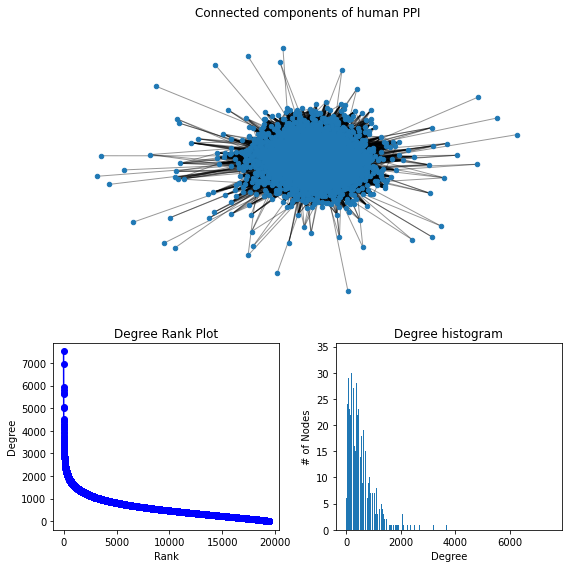

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

human_degree_sequence = sorted([d for n, d in human_ppi.degree()], reverse=True)
human_dmax = max(human_degree_sequence)

fig = plt.figure("Degree of human PPI", figsize=(8, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax0 = fig.add_subplot(axgrid[0:3, :])
Gcc = human_ppi.subgraph(sorted(nx.connected_components(human_ppi), key=len, reverse=True)[0])
pos = nx.spring_layout(Gcc)
nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
ax0.set_title("Connected components of human PPI")
ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(human_degree_sequence, "b-", marker="o")
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")

ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(human_degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("# of Nodes")

fig.tight_layout()
plt.show()

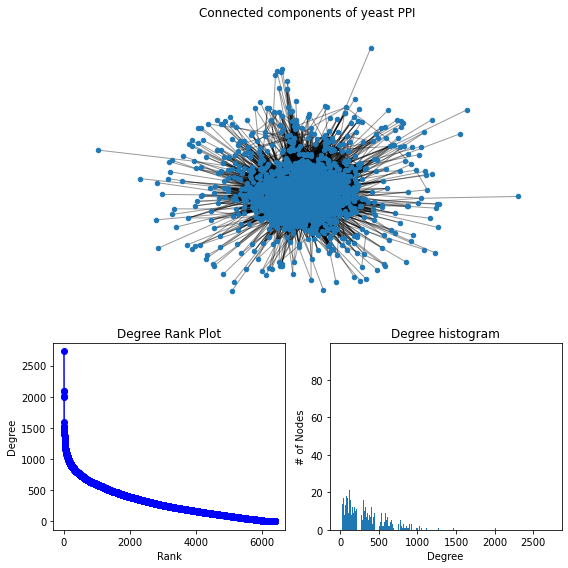

In [ ]:
yeast_degree_sequence = sorted([d for n, d in yeast_ppi.degree()], reverse=True)
yeast_dmax = max(yeast_degree_sequence)

fig = plt.figure("Degree of yeast PPI", figsize=(8, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax0 = fig.add_subplot(axgrid[0:3, :])
Gcc = yeast_ppi.subgraph(sorted(nx.connected_components(yeast_ppi), key=len, reverse=True)[0])
pos = nx.spring_layout(Gcc)
nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
ax0.set_title("Connected components of yeast PPI")
ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(yeast_degree_sequence, "b-", marker="o")
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")

ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(yeast_degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("# of Nodes")

fig.tight_layout()
plt.show()

## Calculate network-related metrics

In [ ]:
human_node_degrees = dict(sorted(human_ppi.degree, key=lambda x: x[1], reverse=True))
human_node_centrality = nx.algorithms.centrality.degree_centrality(human_ppi)

In [ ]:
# need to calculate conserved pairs (why I am removing this???)
# visualise centrality, degree, and num of neighbor
human_protein_measure = {"protein":[], "centrality":[], "degree":[], "evo_type": []}
for i in human_specific:
  human_protein_measure["protein"].append(i)
  human_protein_measure["centrality"].append(human_node_centrality[i])
  human_protein_measure["degree"].append(human_ppi_degrees[i])
  human_protein_measure["evo_type"].append("human_specific")
for i in human_conserved:
  human_protein_measure["protein"].append(i)
  if i not in human_node_centrality:
    human_protein_measure["centrality"].append(None)
    human_protein_measure["degree"].append(None)
    human_protein_measure["evo_type"].append("conserved but not interacted")
  else:
    human_protein_measure["centrality"].append(human_node_centrality[i])
    human_protein_measure["degree"].append(human_ppi_degrees[i])
    human_protein_measure["evo_type"].append("conserved")

In [ ]:
pd.DataFrame(human_protein_measure).describe()

,centrality,degree
count,19385.000000,19385.000000
mean,0.031772,615.862677
std,0.026403,511.788804
min,0.000052,1.000000
25%,0.013104,254.000000
50%,0.025227,489.000000
75%,0.042819,830.000000
max,0.387278,7507.000000


In [ ]:
pd.DataFrame(human_protein_measure)["evo_type"].value_counts().plot(kind="barh")

0        human_specific
1        human_specific
2        human_specific
3        human_specific
4        human_specific
              ...      
19889         conserved
19890         conserved
19891         conserved
19892         conserved
19893         conserved
Name: evo_type, Length: 19894, dtype: object

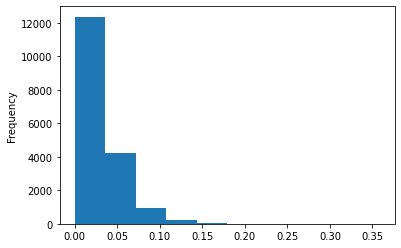

In [ ]:
human_protein_measure_df = pd.DataFrame(human_protein_measure)
human_protein_measure_df[human_protein_measure_df["evo_type"] == "human_specific"]["centrality"].plot(kind="hist")

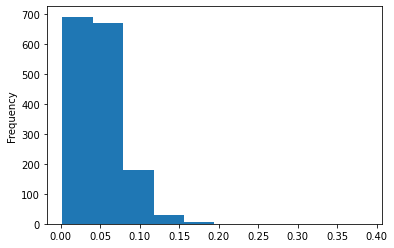

In [ ]:
human_protein_measure_df[human_protein_measure_df["evo_type"] == "conserved"]["centrality"].plot(kind="hist")

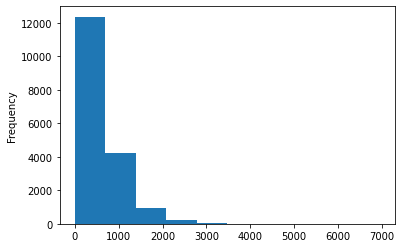

In [ ]:
human_protein_measure_df[human_protein_measure_df["evo_type"] == "human_specific"]["degree"].plot(kind="hist")

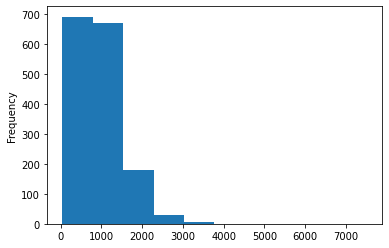

In [ ]:
human_protein_measure_df[human_protein_measure_df["evo_type"] == "conserved"]["degree"].plot(kind="hist")

In [ ]:
# need better visualisation in a figure of the plots above























### Calculate CD distance (only done for 1st degree nodes, need calculation for 2nd degree nodes)

In [ ]:
len([n for n in human_ppi.neighbors("9606.ENSP00000369213")])

1546

In [ ]:
# Liu et al. Complex discovery from weighted PPI networks. Bioinformatics, 25(15):1891-1897, 2009

def neig(node, net):
  return set([n for n in net.neighbors(node)])

def neig_count(node1, node2, net):
  node1_neig = neig(node1, net)
  node2_neig = neig(node2, net)
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  return len(node1_neig), len(node2_neig), len(intersec_neig)

def intersec_neig(node1, node2, net):
  node1_neig = set([n for n in net.neighbors(node1)])
  node2_neig = set([n for n in net.neighbors(node2)])
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  return intersec_neig

# neig_count("9606.ENSP00000075120", "9606.ENSP00000369213", human_ppi)
# intersec_neig("9606.ENSP00000075120", "9606.ENSP00000369213", human_ppi)

In [ ]:
# Adjusted CD Distance
def adj_CD(node1, node2, net, avg_degree):
  # avg_degree = sum(pd.DataFrame(net.degree())[1])/len(pd.DataFrame(net.degree())[0])
  node1_neig = set([n for n in net.neighbors(node1)])
  node2_neig = set([n for n in net.neighbors(node2)])
  intersec_neig = set(node1_neig).intersection(set(node2_neig))
  lambdaU = max(0, avg_degree-len(node1_neig))
  lambdaV = max(0, avg_degree-len(node2_neig))
  distance = 2*len(intersec_neig)/(len(node1_neig)+len(node2_neig)+lambdaU+lambdaV)
  return distance

In [ ]:
human_all_paths = dict(nx.shortest_path_length(human_ppi))
human_all_paths["9606.ENSP00000075120"]["9606.ENSP00000369213"]

In [ ]:
# pre-determine some parameters to speed up calculation...
human_avg_degree = sum(pd.DataFrame(human_ppi.degree())[1])/len(pd.DataFrame(human_ppi.degree())[0])
human_node_num = len(human_ppi_nodes)
adj_CD("9606.ENSP00000075120", "9606.ENSP00000369213", human_ppi, human_avg_degree)

# this approach is even slower than my R scripts, how can I improve this???
adj_CD_table = {"source":[], "target":[], "adj_cd":[]}
iter_num = 0
for source in human_ppi_nodes:
  iter_num += 1
  print(str(iter_num)+"/"+str(len(human_ppi_nodes)))
  connected_to_source = nx.shortest_path_length(human_ppi, source)
  for target in connected_to_source:
    if connected_to_source[target] < 3:
      adj_CD_table["source"].append(source)
      adj_CD_table["target"].append(target)
      adj_CD_table["adj_cd"].append(adj_CD(source, target, human_ppi, human_avg_degree))
pd.DataFrame(adj_CD_table)
pd.DataFrame(adj_CD_table).to_csv("/content/drive/MyDrive/Network_GroupProject/human_adj_CD_table.csv")
human_adj_CD_table = pd.read_csv("/content/drive/MyDrive/Network_GroupProject/human_adj_CD_table.csv")

yeast_avg_degree = sum(pd.DataFrame(yeast_ppi.degree())[1])/len(pd.DataFrame(yeast_ppi.degree())[0])
yeast_node_num = len(yeast_ppi_nodes)
yeast_adj_CD_table = {"source":[], "target":[], "shared":[], "adj_cd":[]}
iter_num = 0
for source in yeast_ppi_nodes:
  iter_num += 1
  print(str(iter_num)+"/"+str(yeast_node_num))
  connected_to_source = nx.shortest_path_length(yeast_ppi, source)
  for target in connected_to_source:
    if connected_to_source[target] < 3:
      yeast_adj_CD_table["source"].append(source)
      yeast_adj_CD_table["target"].append(target)
      yeast_adj_CD_table["adj_cd"].append(adj_CD(source, target, yeast_ppi, yeast_avg_degree))
pd.DataFrame(yeast_adj_CD_table).to_csv("/content/drive/MyDrive/Network_GroupProject/yeast_adj_CD_table.csv")
yeast_adj_CD_table = pd.read_csv("/content/drive/MyDrive/Network_GroupProject/yeast_adj_CD_table.csv")

In [ ]:
# for the use of progress bar, please read https://zhuanlan.zhihu.com/p/403641309
!pip install tqdm
from tqdm.notebook import tqdm 
tqdm.pandas(desc="How stupid this script is!")

In [ ]:
# Let's make this simpler: just get the CD distance of the edge list
human_avg_degree = sum(pd.DataFrame(human_ppi.degree())[1])/len(pd.DataFrame(human_ppi.degree())[0])
human_node_num = len(human_ppi_nodes)
human_ppi_edges["CD_distance"] = human_ppi_edges.progress_apply(lambda row: adj_CD(row["protein1"], row["protein2"], human_ppi, human_avg_degree), axis = 1)

yeast_avg_degree = sum(pd.DataFrame(yeast_ppi.degree())[1])/len(pd.DataFrame(yeast_ppi.degree())[0])
yeast_node_num = len(yeast_ppi_nodes)
yeast_ppi_edges["CD_distance"] = yeast_ppi_edges.progress_apply(lambda row: adj_CD(row["protein1"], row["protein2"], yeast_ppi, yeast_avg_degree), axis = 1)

How stupid this script is!:   0%|          | 0/11938498 [00:00<?, ?it/s]

How stupid this script is!:   0%|          | 0/1988592 [00:00<?, ?it/s]

In [ ]:
human_ppi_edges.to_csv("/content/drive/MyDrive/Network_GroupProject/human_ppi_edges_with_cd.csv")
yeast_ppi_edges.to_csv("/content/drive/MyDrive/Network_GroupProject/yeast_ppi_edges_with_cd.csv")

In [ ]:
human_ppi_edges
# there will be several scenarios:
# 1. protein1 is conserved but protein2 is not
# 2. protein1 is conserved but protein2 is also conserved
# 2. protein1 is not conserved but protein2 is conserved
# 2. protein1 is not conserved but protein2 is not conserved

# please calculate the number of pairs and then further investigate:
# 1) how the network related metrics affect the 4 possible states
# 2) how we can predict the states with our known parameters

,protein1,protein2,combined_score,CD_distance
0,9606.ENSP00000000233,9606.ENSP00000379496,155,0.104607
1,9606.ENSP00000000233,9606.ENSP00000314067,197,0.300442
2,9606.ENSP00000000233,9606.ENSP00000263116,222,0.295290
3,9606.ENSP00000000233,9606.ENSP00000361263,181,0.241210
4,9606.ENSP00000000233,9606.ENSP00000409666,270,0.177916
...,...,...,...,...
11938493,9606.ENSP00000485678,9606.ENSP00000354800,213,0.094177
11938494,9606.ENSP00000485678,9606.ENSP00000308270,151,0.050336
11938495,9606.ENSP00000485678,9606.ENSP00000335660,181,0.058455
11938496,9606.ENSP00000485678,9606.ENSP00000300127,154,0.045465


Note that evolution does not necessarily imply functional similarity, but just similarity. We are interested in the probabability of each edge to continue or dissolve during evolution, especially:

- Whether this is significantly impacted by certain network related metrics (especially shared number of neighbours, indicated by CD distance) and how can network-related metrics improve our prediction of continuation/discontinuation states of protein-protein interaction.

- Also, we aim to describe the popularity of the interactions continuation or discontinuation and whether the percentage of changed interaction of each node or each functional modules can be described or predicted with network/evolution-related metrics. (We may calculate the evolutionary change rate in the same way of CD distance adjustment...)

In [ ]:
# Please read the doc I provide for more details about what to do...

In [ ]:
### A next step I am working on... 

# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2718639/
# TODO: functional module identification. 
# We will construct subnetworks with the modules to see how they evolve
# Please read: https://github.com/kgori/treeCl 
# This package is helpful to identify evolutionarily related proteins/genes family
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4868114/
# https://www.frontiersin.org/articles/10.3389/fgene.2019.00164/full


In [ ]:
# About missing proteins
# https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0177029#sec012
# A good paper using STRING database

In [ ]:
from networkx.algorithms import community
human_ppi_communities = community.greedy_modularity_communities(human_ppi)
yeast_ppi_communities = community.greedy_modularity_communities(yeast_ppi)

In [ ]:
len(yeast_ppi_communities)

9

### Using Snap, an alternative to Networkx

In [ ]:
# https://snap.stanford.edu/snappy
! pip install snap-stanford
! sudo apt install graphviz gnuplot

     |████████████████████████████████| 11.6 MB 28.9 MB/s 
Reading package lists... Done
Building dependency tree       
Reading state information... Done
graphviz is already the newest version (2.40.1-2).
The following additional packages will be installed:
  aglfn gnuplot-data gnuplot-qt libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common liblua5.3-0 libnotify4 libqt5svg5
  libwxbase3.0-0v5 libwxgtk3.0-0v5 notification-daemon
Suggested packages:
  gnuplot-doc gvfs
The following NEW packages will be installed:
  aglfn gnuplot gnuplot-data gnuplot-qt libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common liblua5.3-0 libnotify4 libqt5svg5
  libwxbase3.0-0v5 libwxgtk3.0-0v5 notification-daemon
0 upgraded, 15 newly installed, 0 to remove and 37 not upgraded.
Need to get 8,564 kB of archives.
After this operation, 31.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/main amd64 libqt5svg5 amd64 5.9.5-0ubuntu1 [128 kB]


In [ ]:
import pandas as pd
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
pd.read_csv("/content/drive/MyDrive/Network_GroupProject/string_human.txt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,protein1 protein2 combined_score
0,9606.ENSP00000000233 9606.ENSP00000379496 155
1,9606.ENSP00000000233 9606.ENSP00000314067 197
2,9606.ENSP00000000233 9606.ENSP00000263116 222
3,9606.ENSP00000000233 9606.ENSP00000361263 181
4,9606.ENSP00000000233 9606.ENSP00000409666 270
...,...
11938493,9606.ENSP00000485678 9606.ENSP00000354800 213
11938494,9606.ENSP00000485678 9606.ENSP00000308270 151
11938495,9606.ENSP00000485678 9606.ENSP00000335660 181
11938496,9606.ENSP00000485678 9606.ENSP00000300127 154


In [ ]:
degree_cent = nx.degree_centrality(graph)
eigen_cent = nx.eigenvector_centrality(graph)

RuntimeError: ignored

In [ ]:
net = human_ppi_Snaptable.ToNetwork(snap.TNEANet, "protein1", "protein2",snap.aaFirst)

In [ ]:
net

<snap.PNEANet; proxy of <Swig Object of type 'PNEANet *' at 0x7f7287899240> >

In [ ]:
net.PlotSccDistr("human_ppi_SccDistr.png", "Human PPI scc distribution")

In [ ]:
net.PlotWccDistr("human_ppi_WccDistr.png", "Human PPI wcc distribution")

In [ ]:
net.PlotClustCf("human_ppi_ClustCf.png", "Human PPI clustering coefficient")

In [ ]:
net.PlotInDegDistr("human_ppi_InDegDistr.png", "Human PPI in-degree Distribution")

In [ ]:
net.PlotOutDegDistr("human_ppi_OutDegDistr.png", "Human PPI out-degree Distribution")

In [ ]:
net.PlotHops("human_ppi_Hops.png", "Human PPI hops", False, 1024)

In [ ]:
# takes too long to run...
# net.PlotShortPathDistr("human_ppi_ShortPathDistr.png", "Human PPI shortest path")

In [ ]:
net.DrawGViz(snap.gvlNeato, "human_ppi.png", " ", False)

In [ ]:
NTestNodes = 100
IsDir = False
EffDiam = net.GetBfsEffDiam(NTestNodes, IsDir)
print(EffDiam)

1.969811556792139


In [ ]:
i
protein_evo_details = pd.read_csv("/content/drive/MyDrive/Network_GroupProject/protein_evo_details.txt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
protein_evo_details[["Last common ancestor with Human"]].value_counts()

Last common ancestor with Human
Opisthokonta                       6766
dtype: int64

In [ ]:
protein_evo_details

,Gene stable ID,Transcript stable ID,Human gene name,Human protein or transcript stable ID,%id. target Human gene identical to query gene,%id. query gene identical to target Human gene,Human homology type,Last common ancestor with Human,Protein stable ID
0,YBR024W,YBR024W_mRNA,SCO1,ENSP00000255390,29.9003,29.9003,ortholog_many2many,Opisthokonta,YBR024W
1,YBR024W,YBR024W_mRNA,SCO2,ENSP00000379046,24.2525,27.4436,ortholog_many2many,Opisthokonta,YBR024W
2,YDL245C,YDL245C_mRNA,SLC2A3,ENSP00000075120,22.9277,26.2097,ortholog_many2many,Opisthokonta,YDL245C
3,YDL245C,YDL245C_mRNA,SLC2A14,ENSP00000407287,22.5750,25.7545,ortholog_many2many,Opisthokonta,YDL245C
4,YDL245C,YDL245C_mRNA,SLC2A7,ENSP00000383698,19.7531,21.8750,ortholog_many2many,Opisthokonta,YDL245C
...,...,...,...,...,...,...,...,...,...
11236,YGR161W-B,YGR161W-B,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11237,YCL019W,YCL019W,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11238,YLR227W-B,YLR227W-B,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11239,YOL103W-A,YOL103W-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# <?xml version="1.0" encoding="UTF-8"?> <!DOCTYPE Query> <Query  virtualSchemaName = "default" formatter = "FASTA" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" > <Dataset name = "scerevisiae_gene_ensembl" interface = "default" > <Attribute name = "peptide" /> <Attribute name = "ensembl_gene_id" /> <Attribute name = "ensembl_transcript_id" /> <Attribute name = "ensembl_peptide_id" /> </Dataset> </Query>

In [ ]:
! wget -O /content/drive/MyDrive/Network_GroupProject/yeast_protein_info.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query><Query  virtualSchemaName = "default" formatter = "TSV" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" ><Dataset name = "scerevisiae_gene_ensembl" interface = "default" ><Attribute name = "ensembl_gene_id" /><Attribute name = "ensembl_transcript_id" /><Attribute name = "ensembl_peptide_id" /><Attribute name = "namespace_1003" /><Attribute name = "go_id" /><Attribute name = "name_1006" /><Attribute name = "goslim_goa_accession" /><Attribute name = "goslim_goa_description" /><Attribute name = "kegg_enzyme" /></Dataset></Query>'

--2021-10-05 06:56:07--  http://www.ensembl.org/biomart/martservice?query=%3C?xml%20version=%221.0%22%20encoding=%22UTF-8%22?%3E%3C!DOCTYPE%20Query%3E%3CQuery%20%20virtualSchemaName%20=%20%22default%22%20formatter%20=%20%22TSV%22%20header%20=%20%220%22%20uniqueRows%20=%20%220%22%20count%20=%20%22%22%20datasetConfigVersion%20=%20%220.6%22%20%3E%3CDataset%20name%20=%20%22scerevisiae_gene_ensembl%22%20interface%20=%20%22default%22%20%3E%3CAttribute%20name%20=%20%22ensembl_gene_id%22%20/%3E%3CAttribute%20name%20=%20%22ensembl_transcript_id%22%20/%3E%3CAttribute%20name%20=%20%22ensembl_peptide_id%22%20/%3E%3CAttribute%20name%20=%20%22namespace_1003%22%20/%3E%3CAttribute%20name%20=%20%22go_id%22%20/%3E%3CAttribute%20name%20=%20%22name_1006%22%20/%3E%3CAttribute%20name%20=%20%22goslim_goa_accession%22%20/%3E%3CAttribute%20name%20=%20%22goslim_goa_description%22%20/%3E%3CAttribute%20name%20=%20%22kegg_enzyme%22%20/%3E%3C/Dataset%3E%3C/Query%3E
Resolving www.ensembl.org (www.ensembl.org)... 193

In [ ]:
! wget -O /content/drive/MyDrive/Network_GroupProject/human_protein_info.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?> <!DOCTYPE Query> <Query  virtualSchemaName = "default" formatter = "TSV" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" > <Dataset name = "hsapiens_gene_ensembl" interface = "default" > <Attribute name = "ensembl_gene_id" /> <Attribute name = "ensembl_transcript_id" /> <Attribute name = "ensembl_peptide_id" /> <Attribute name = "namespace_1003" /> <Attribute name = "go_id" /> <Attribute name = "name_1006" /> <Attribute name = "goslim_goa_accession" /> <Attribute name = "kegg_enzyme" /> </Dataset> </Query>'

--2021-10-05 10:02:04--  http://www.ensembl.org/biomart/martservice?query=%3C?xml%20version=%221.0%22%20encoding=%22UTF-8%22?%3E%20%3C!DOCTYPE%20Query%3E%20%3CQuery%20%20virtualSchemaName%20=%20%22default%22%20formatter%20=%20%22TSV%22%20header%20=%20%220%22%20uniqueRows%20=%20%220%22%20count%20=%20%22%22%20datasetConfigVersion%20=%20%220.6%22%20%3E%20%3CDataset%20name%20=%20%22hsapiens_gene_ensembl%22%20interface%20=%20%22default%22%20%3E%20%3CAttribute%20name%20=%20%22ensembl_gene_id%22%20/%3E%20%3CAttribute%20name%20=%20%22ensembl_transcript_id%22%20/%3E%20%3CAttribute%20name%20=%20%22ensembl_peptide_id%22%20/%3E%20%3CAttribute%20name%20=%20%22namespace_1003%22%20/%3E%20%3CAttribute%20name%20=%20%22go_id%22%20/%3E%20%3CAttribute%20name%20=%20%22name_1006%22%20/%3E%20%3CAttribute%20name%20=%20%22goslim_goa_accession%22%20/%3E%20%3CAttribute%20name%20=%20%22kegg_enzyme%22%20/%3E%20%3C/Dataset%3E%20%3C/Query%3E
Resolving www.ensembl.org (www.ensembl.org)... 193.62.193.83
Connecting to 

In [ ]:
# http://www.ensembl.org/biomart/martservice?query=

In [ ]:
! wget -O /content/drive/MyDrive/Network_GroupProject/yeast_protein_AA.txt '# http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?> <!DOCTYPE Query> <Query  virtualSchemaName = "default" formatter = "FASTA" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" > <Dataset name = "scerevisiae_gene_ensembl" interface = "default" > <Attribute name = "peptide" /> <Attribute name = "ensembl_gene_id" /> <Attribute name = "ensembl_transcript_id" /> <Attribute name = "ensembl_peptide_id" /> </Dataset> </Query>'

In [ ]:
! wget -O /content/drive/MyDrive/Network_GroupProject/human_protein_AA.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?> <!DOCTYPE Query> <Query  virtualSchemaName = "default" formatter = "FASTA" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" > <Dataset name = "hsapiens_gene_ensembl" interface = "default" > <Attribute name = "peptide" /> <Attribute name = "ensembl_gene_id" /> <Attribute name = "ensembl_transcript_id" /> </Dataset> </Query>'